In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

In [2]:
df = pd.read_csv("News_sentiment.csv")

C:\Users\Parth Rana\AppData\Local\Temp\ipykernel_3852\1999285535.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("News_sentiment.csv")


In [3]:
print(df.head(3))
print(df.info())
print(df.isnull().sum())

         Date                                              Title  \
0  01-01-2017  2017 brings with it things that make us feel c...   
1  01-01-2017  889 prosecuted for drunken driving on New Year...   
2  01-01-2017  After PM Narendra Modi rebuke , SBI makes firs...   

                                                 URL sentiment  confidence  \
0  /Opinion/PIJU7j1bD9L45mKDbN20eP/2017-brings-wi...  POSITIVE    0.998965   
1  /india-news/889-prosecuted-for-drunken-driving...  NEGATIVE   -0.995371   
2  /industry/banking-finance/after-pm-narendra-mo...  POSITIVE    0.975815   

   Unnamed: 5 Unnamed: 6  
0         NaN        NaN  
1         NaN        NaN  
2         NaN        NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200500 entries, 0 to 200499
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Date        200500 non-null  object 
 1   Title       200500 non-null  object 
 2   URL         200499 non-

In [4]:
df = df.drop(columns=['URL', 'Unnamed: 5', 'Unnamed: 6'], errors='ignore')
df.sample()

,Date,Title,sentiment,confidence
162119,21-05-2020,"Recession : Covid , lockdown , recession ... W...",NEGATIVE,-0.997774


In [5]:
df.rename(columns={
    'Title': 'text',
    'sentiment': 'label'
}, inplace=True)

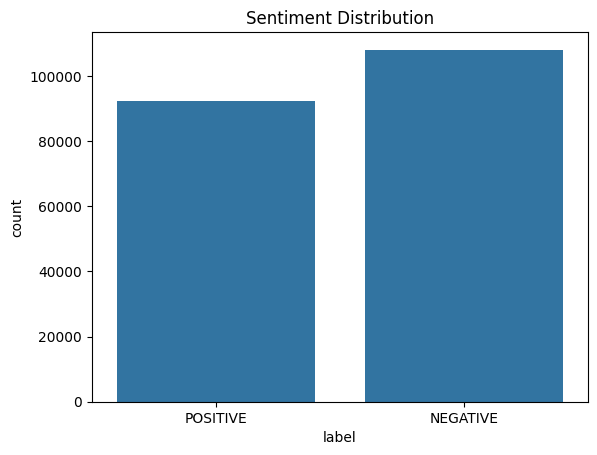

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['label'])
plt.title("Sentiment Distribution")
plt.show()

In [7]:
df.sample()

,Date,text,label,confidence
87401,03-10-2018,Flipkart rides on stars in sale blitz,POSITIVE,0.991232


In [8]:
df['label'].unique()

array(['POSITIVE', 'NEGATIVE'], dtype=object)

In [9]:
for i in range(5):
    print(df['text'][i])
    print(df['label'][i])
    print("-----")

2017 brings with it things that make us feel cleaner
POSITIVE
-----
889 prosecuted for drunken driving on New Year eve
NEGATIVE
-----
After PM Narendra Modi rebuke , SBI makes first move , cuts lending rate by 90 bps across maturities
POSITIVE
-----
After SBI , Punjab National Bank cuts lending rate by 70 bps
NEGATIVE
-----
Amit Shah welcomes lowering of interest rates by banks
POSITIVE
-----


In [10]:
df = df[['text', 'label']]

In [11]:
df.shape

(200500, 2)

In [12]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)   # remove numbers & symbols
    text = re.sub(r"\s+", " ", text)         # remove extra spaces
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

In [14]:
df['clean_text'].sample(3)

56868    tata steel hr must drive transformation within...
37967    news live fed divide on inflation intensified ...
22667    infosys ceo vishal sikka allays hb visa fears ...
Name: clean_text, dtype: object

In [15]:
MAX_WORDS = 20000
tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(df['clean_text'])

In [16]:
sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [30]:
MAX_LEN = 50
X = pad_sequences(sequences, maxlen=MAX_LEN)

In [31]:
y = df['label']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

In [34]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=200,    # embedding size
    window=5,
    min_count=2,
    workers=4
)

In [35]:
word_index = tokenizer.word_index

embedding_dim = 200

embedding_matrix = np.zeros((MAX_WORDS, embedding_dim))

In [36]:
for word, i in word_index.items():

    if i >= MAX_WORDS:
        continue

    if word in w2v_model.wv:

        embedding_matrix[i] = w2v_model.wv[word]

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

In [50]:
model = Sequential()

model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    )
)

model.add(
    Bidirectional(
        LSTM(64)
    )
)

model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

In [51]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [55]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 142s 141ms/step - accuracy: 0.9079 - loss: 0.2155 - val_accuracy: 0.8080 - val_loss: 0.5645
Epoch 2/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 152s 151ms/step - accuracy: 0.9226 - loss: 0.1820 - val_accuracy: 0.8015 - val_loss: 0.6456
Epoch 3/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 153s 152ms/step - accuracy: 0.9332 - loss: 0.1574 - val_accuracy: 0.8048 - val_loss: 0.7610


In [56]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8048 - loss: 0.5747
Accuracy: 0.8047880530357361


In [57]:
def predict_sentiment(text):

    sequence = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(sequence, maxlen=MAX_LEN)

    prediction = model.predict(padded)

    if prediction[0][0] > 0.5:
        return "POSITIVE"
    else:
        return "NEGATIVE"

In [58]:
print(predict_sentiment("Stock market crashes after inflation fears"))

print(predict_sentiment("Company profits rise sharply this quarter"))

print(predict_sentiment("Investors are happy with strong earnings"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
NEGATIVE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
NEGATIVE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
POSITIVE


In [59]:
model.save("sentiment_lstm_model.h5")

In [60]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)